In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier , BaggingClassifier , RandomForestClassifier , GradientBoostingClassifier

In [3]:
df = pd.read_csv(r"D:\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\Downloads\weather_classification_data.csv")
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14,73,9.5,82,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39,96,8.5,71,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30,64,7.0,16,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38,83,1.5,82,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27,74,17.0,66,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [4]:
cloud_cover_encoder = LabelEncoder()
season_encoder = LabelEncoder()
location_encoder = LabelEncoder()
waather_type_encoder = LabelEncoder()

In [5]:
df["Cloud Cover"] = cloud_cover_encoder.fit_transform(df["Cloud Cover"])
df["Season"] = cloud_cover_encoder.fit_transform(df["Season"])
df["Location"] = cloud_cover_encoder.fit_transform(df["Location"])
df["Weather Type"] = cloud_cover_encoder.fit_transform(df["Weather Type"])
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14,73,9.5,82,3,1010.82,2,3,3.5,1,1
1,39,96,8.5,71,3,1011.43,7,1,10.0,1,0
2,30,64,7.0,16,0,1018.72,5,1,5.5,2,3
3,38,83,1.5,82,0,1026.25,7,1,1.0,0,3
4,27,74,17.0,66,2,990.67,1,3,2.5,2,1


<Axes: >

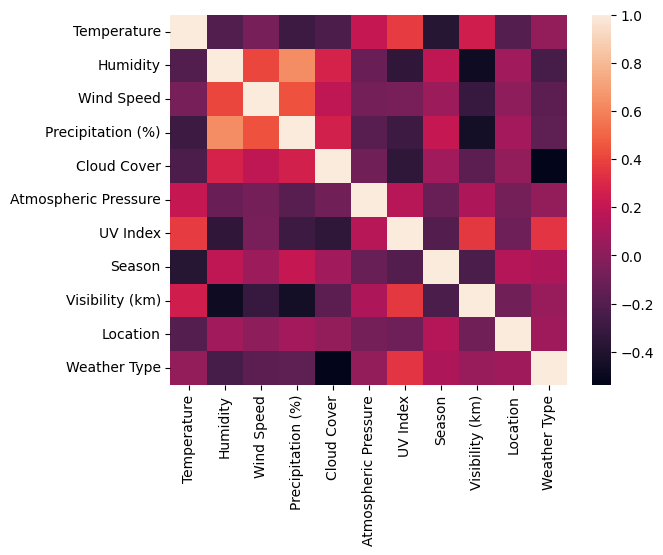

In [5]:
sns.heatmap(df.corr())

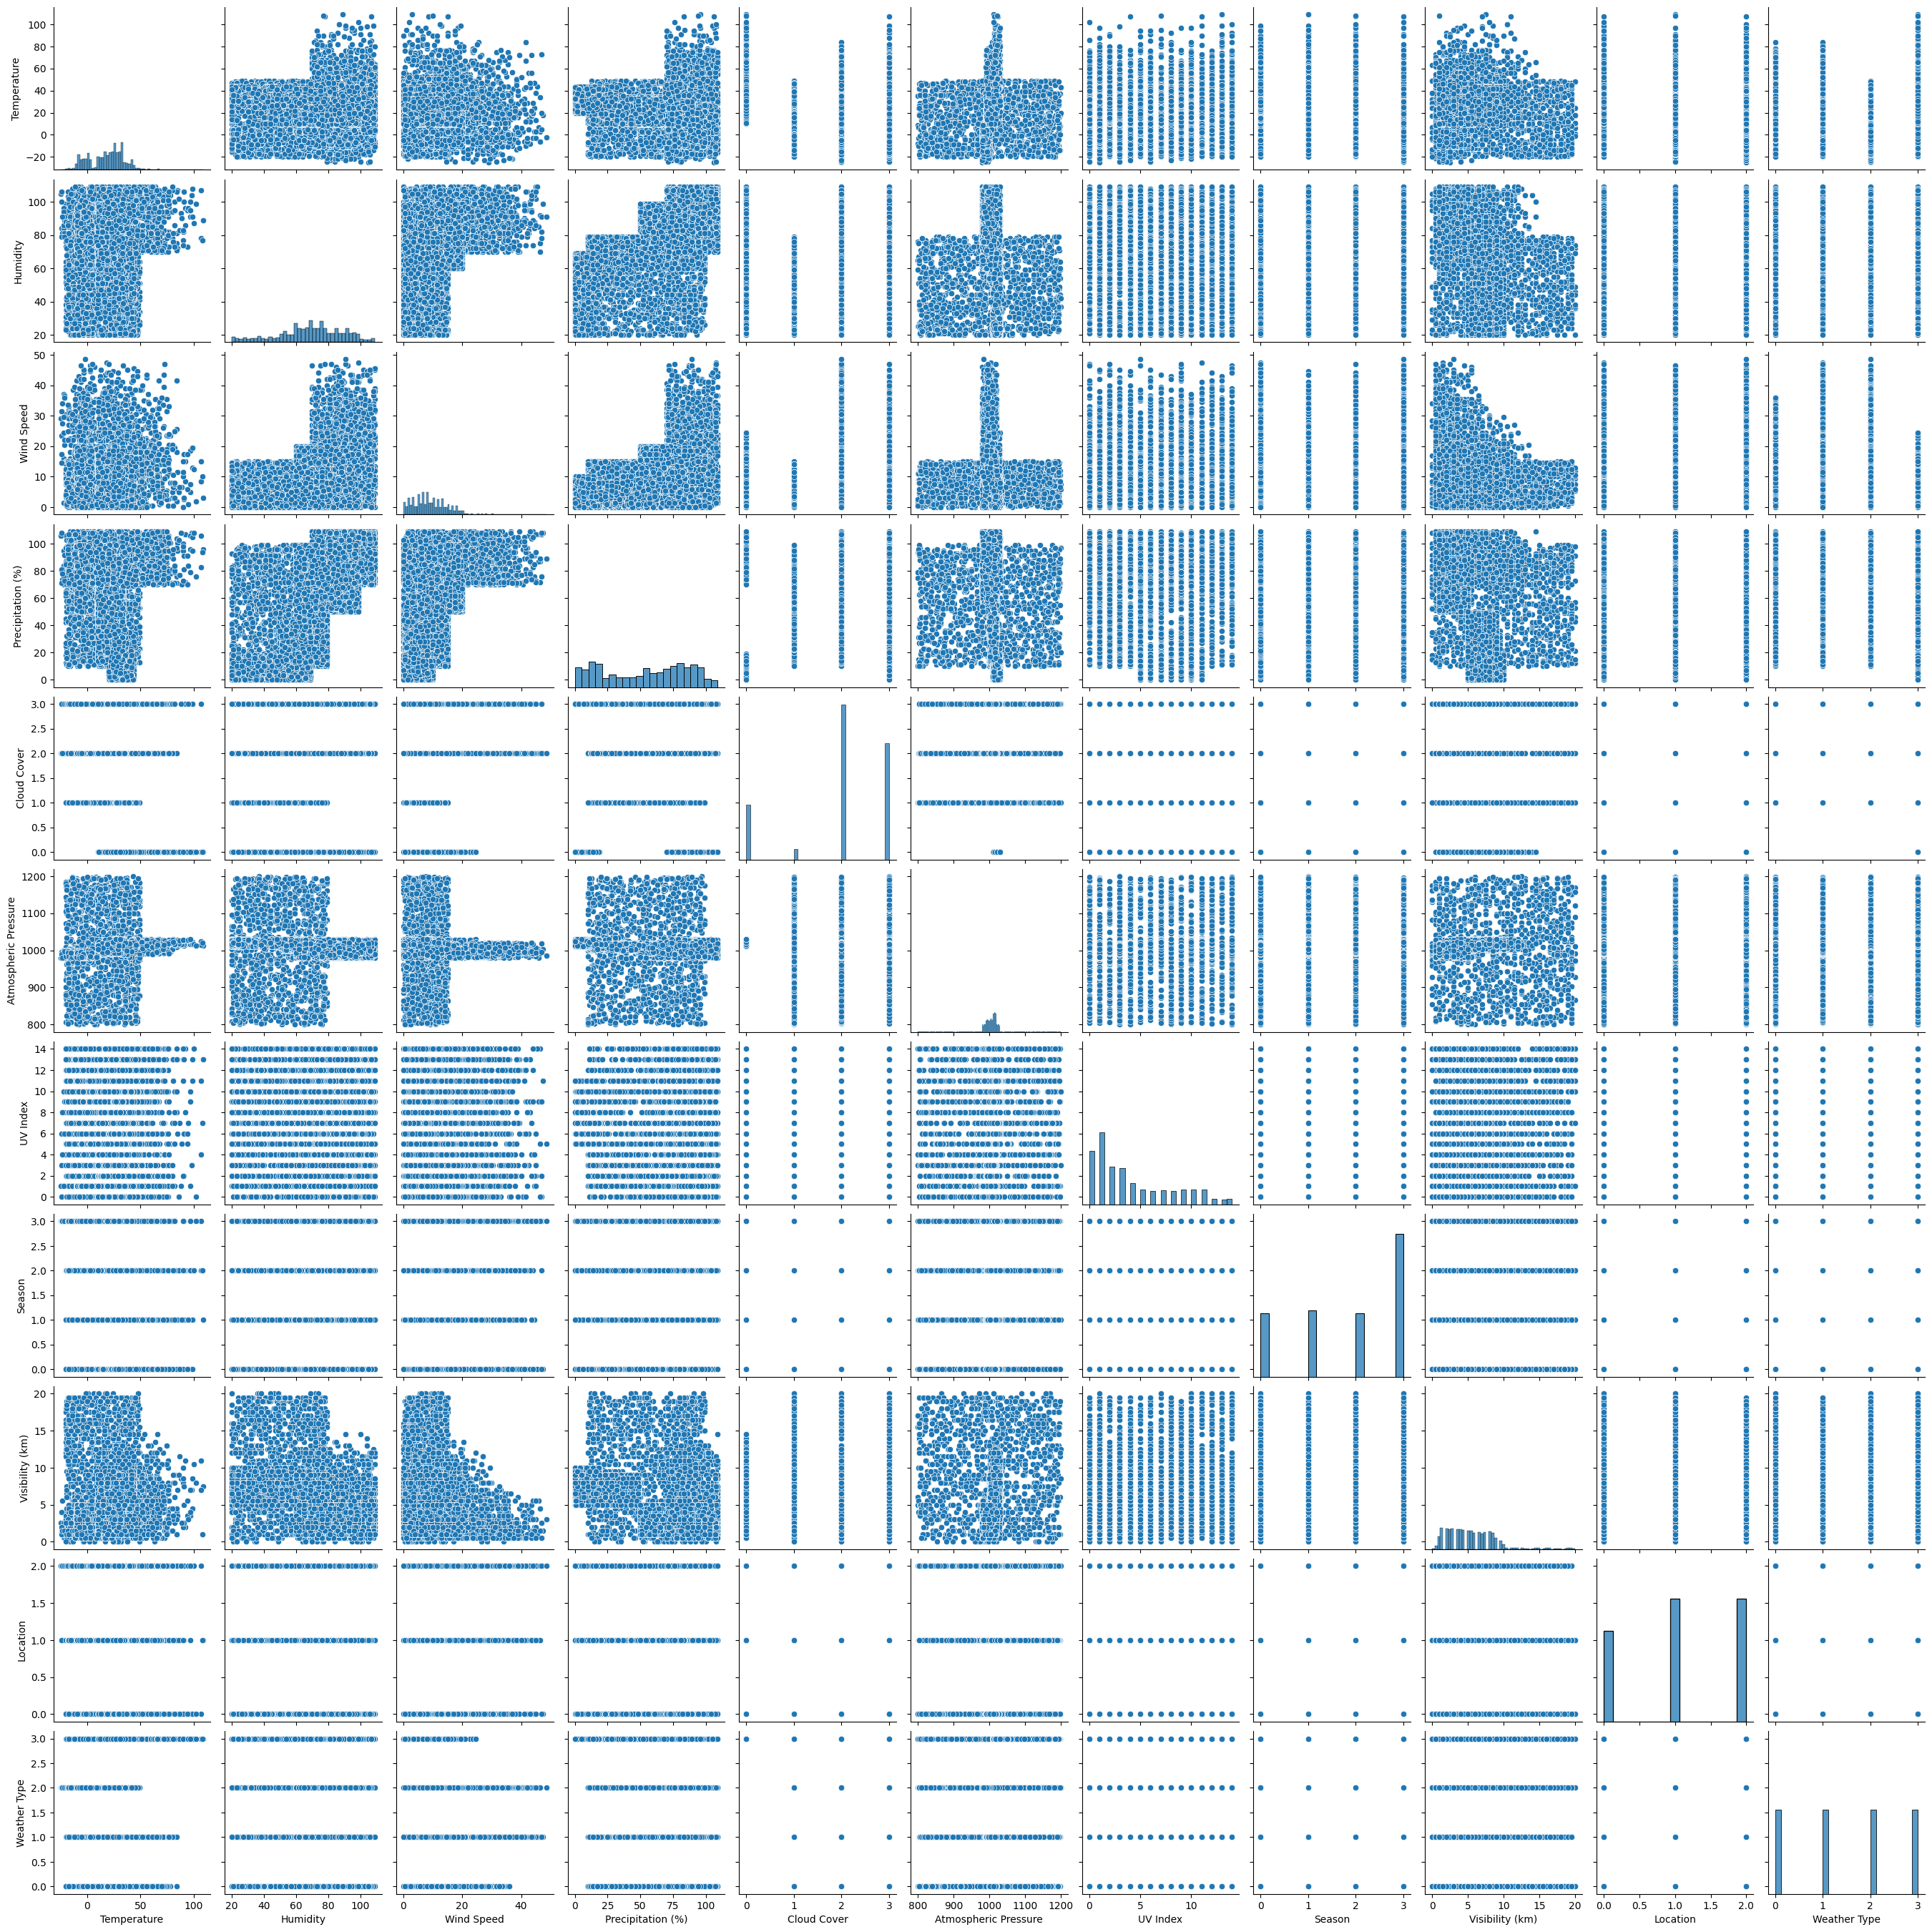

In [6]:
sns.pairplot(df)

# Copy df and Normalize the copied DF 

In [7]:
scaler = StandardScaler()
scaled_df = df.copy()
scaled_df[["Temperature" ,"Humidity" ,"Wind Speed" ,"Precipitation (%)" ,"Atmospheric Pressure" ,"UV Index" ,"Visibility (km)" ]] = scaler.fit_transform(df[["Temperature" ,"Humidity" ,"Wind Speed" ,"Precipitation (%)" ,"Atmospheric Pressure" ,"UV Index" ,"Visibility (km)" ]])
scaled_df

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,-0.294931,0.212404,-0.048086,0.887629,3,0.134203,-0.520104,3,-0.582231,1,1
1,1.143035,1.351385,-0.192836,0.543291,3,0.150602,0.776424,1,1.345768,1,0
2,0.625367,-0.233285,-0.409962,-1.178401,0,0.346579,0.257813,1,0.010999,2,3
3,1.085516,0.707613,-1.206089,0.887629,0,0.549008,0.776424,1,-1.323769,0,3
4,0.452811,0.261924,1.037543,0.386773,2,-0.407490,-0.779410,3,-0.878846,2,1
...,...,...,...,...,...,...,...,...,...,...,...
13195,-0.525006,0.261924,0.675666,0.543291,2,-0.071990,-0.779410,2,-1.323769,2,1
13196,-1.157711,0.360966,-0.916588,-0.959276,1,1.650675,-0.779410,3,0.159307,0,2
13197,0.625367,0.410487,-0.627087,-0.802759,2,0.184474,-0.260799,0,1.049153,0,0
13198,-0.927636,0.360966,0.024290,1.263271,2,-0.579542,-1.038715,3,-1.027154,1,2


# KNN

In [8]:
x = scaled_df.iloc[: , 0:10]
y = scaled_df.iloc[: , -1]
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.25 , random_state = 42)
x_train

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location
11315,-1.330267,1.301864,-0.192836,0.292863,2,-0.431147,-0.779410,3,-1.175461,1
6282,1.200553,-0.827536,-1.423215,-1.679256,0,0.500619,0.776424,0,1.049153,0
9415,0.625367,0.905696,0.820417,0.511987,2,-0.327648,-0.779410,2,-0.433923,0
4004,1.027998,1.400906,1.833670,1.388485,0,0.442282,2.072951,2,-0.285616,1
1245,-1.100192,1.153301,-0.409962,1.200664,2,-0.314206,-1.038715,3,-1.323769,1
...,...,...,...,...,...,...,...,...,...,...
11964,0.740404,1.450427,-0.627087,1.106753,2,0.018337,-0.520104,1,-0.878846,0
5191,1.258072,0.509529,0.603291,-1.147097,2,-1.258607,2.591563,2,-1.323769,2
5390,0.855442,-0.827536,-0.409962,-1.272311,2,0.093341,-0.779410,2,0.752538,0
860,-0.582524,0.212404,0.024290,0.950236,2,-0.155059,2.591563,1,0.752538,2


In [9]:
params = {
    "n_neighbors" : [5 , 10 , 15 , 20],
    "algorithm" : ['auto', 'ball_tree', 'kd_tree', 'brute']
}
grid_search_cv = GridSearchCV(
    estimator=KNeighborsClassifier(n_jobs=-1),
    param_grid= params,
    n_jobs=-1,
    cv = 10,
)

grid_search_cv.fit(x_train , y_train)

,estimator,KNeighborsCla...ier(n_jobs=-1)
,param_grid,"{'algorithm': ['auto', 'ball_tree', ...], 'n_neighbors': [5, 10, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,5


In [10]:
knn = grid_search_cv.best_estimator_
y_pred = knn.predict(x_test)
accuracy_score(y_test , y_pred)

0.8939393939393939

# Decision tree


In [11]:
x = df.iloc[: , 0:10]
y = df.iloc[: , -1]
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.25 , random_state = 42)
x_train

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location
11315,-4,95,8.5,63,2,989.79,1,3,1.5,1
6282,40,52,0.0,0,0,1024.45,7,0,9.0,0
9415,30,87,15.5,70,2,993.64,1,2,4.0,0
4004,37,97,22.5,98,0,1022.28,12,2,4.5,1
1245,0,92,7.0,92,2,994.14,0,3,1.0,1
...,...,...,...,...,...,...,...,...,...,...
11964,32,98,5.5,89,2,1006.51,2,1,2.5,0
5191,41,79,14.0,17,2,959.01,14,2,1.0,2
5390,34,52,7.0,13,2,1009.30,1,2,8.0,0
860,9,73,10.0,84,2,1000.06,14,1,8.0,2


In [12]:
grid_search_cv = GridSearchCV(
    estimator= DecisionTreeClassifier(),
    param_grid={ "max_depth":[5,10,15,20,25,30]},
    n_jobs=-1,
    cv=15
)
grid_search_cv.fit(x_train , y_train)

grid_search_cv.best_params_

{'max_depth': 30}

In [13]:
dt = grid_search_cv.best_estimator_
y_pred = dt.predict(x_test)
accuracy_score(y_test , y_pred)

0.9084848484848485

# logistic regression

In [6]:
x = df.iloc[: , 0:10]
y = df.iloc[: , -1]

x_scaler = StandardScaler()

x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.25 , random_state = 42)

x_train[["Temperature" ,"Humidity" ,"Wind Speed" ,"Precipitation (%)" ,"Atmospheric Pressure" ,"UV Index" ,"Visibility (km)" ]] = x_scaler.fit_transform(x_train[["Temperature" ,"Humidity" ,"Wind Speed" ,"Precipitation (%)" ,"Atmospheric Pressure" ,"UV Index" ,"Visibility (km)" ]])
x_test[["Temperature" ,"Humidity" ,"Wind Speed" ,"Precipitation (%)" ,"Atmospheric Pressure" ,"UV Index" ,"Visibility (km)" ]] = x_scaler.transform(x_test[["Temperature" ,"Humidity" ,"Wind Speed" ,"Precipitation (%)" ,"Atmospheric Pressure" ,"UV Index" ,"Visibility (km)" ]])

In [11]:
lr = LogisticRegression()
lr.fit(x_train , y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [16]:
y_pred = lr.predict(x_test)
print(accuracy_score(y_test , y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)

0.850909090909091
[[651  73  21  52]
 [ 37 698  57  30]
 [ 27   7 811  20]
 [ 89  57  22 648]]


# support vector classifier

In [17]:
x = scaled_df.iloc[: , 0:10]
y = scaled_df.iloc[: , -1]
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.25 , random_state = 42)
x_train

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location
11315,-1.330267,1.301864,-0.192836,0.292863,2,-0.431147,-0.779410,3,-1.175461,1
6282,1.200553,-0.827536,-1.423215,-1.679256,0,0.500619,0.776424,0,1.049153,0
9415,0.625367,0.905696,0.820417,0.511987,2,-0.327648,-0.779410,2,-0.433923,0
4004,1.027998,1.400906,1.833670,1.388485,0,0.442282,2.072951,2,-0.285616,1
1245,-1.100192,1.153301,-0.409962,1.200664,2,-0.314206,-1.038715,3,-1.323769,1
...,...,...,...,...,...,...,...,...,...,...
11964,0.740404,1.450427,-0.627087,1.106753,2,0.018337,-0.520104,1,-0.878846,0
5191,1.258072,0.509529,0.603291,-1.147097,2,-1.258607,2.591563,2,-1.323769,2
5390,0.855442,-0.827536,-0.409962,-1.272311,2,0.093341,-0.779410,2,0.752538,0
860,-0.582524,0.212404,0.024290,0.950236,2,-0.155059,2.591563,1,0.752538,2


In [18]:
grid_search_cv = GridSearchCV(
    estimator= SVC(),
    param_grid={
        "kernel" : ['linear', 'poly', 'rbf', 'sigmoid'],
        "degree" : [1,2,3,4,5]
    },
    n_jobs=-1,
    cv=15
)

grid_search_cv.fit(x_train , y_train)

,estimator,SVC()
,param_grid,"{'degree': [1, 2, ...], 'kernel': ['linear', 'poly', ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,15
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1.0


In [19]:
svc = grid_search_cv.best_estimator_
y_pred = svc.predict(x_test)
accuracy_score(y_test , y_pred)

0.9051515151515152

# Voting classifier

In [30]:
vc = VotingClassifier(
    estimators=[
        ('lr' , LogisticRegression(max_iter=200)),
        ('dt' , DecisionTreeClassifier(max_depth=20)),
        ('svc' , SVC()),
        ('knn' ,KNeighborsClassifier())
    ],
    voting="hard",
    n_jobs=-1
)
vc.fit(x_train , y_train)

,estimators,"[('lr', ...), ('dt', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,-1
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [31]:
y_pred = vc.predict(x_test)
accuracy_score(y_test , y_pred)

0.8836363636363637

# Bagging Classifier

In [33]:
x = df.iloc[: , 0:10]
y = df.iloc[: , -1]
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.25 , random_state = 42)
x_train

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location
11315,-4,95,8.5,63,2,989.79,1,3,1.5,1
6282,40,52,0.0,0,0,1024.45,7,0,9.0,0
9415,30,87,15.5,70,2,993.64,1,2,4.0,0
4004,37,97,22.5,98,0,1022.28,12,2,4.5,1
1245,0,92,7.0,92,2,994.14,0,3,1.0,1
...,...,...,...,...,...,...,...,...,...,...
11964,32,98,5.5,89,2,1006.51,2,1,2.5,0
5191,41,79,14.0,17,2,959.01,14,2,1.0,2
5390,34,52,7.0,13,2,1009.30,1,2,8.0,0
860,9,73,10.0,84,2,1000.06,14,1,8.0,2


In [41]:
params = {
    "n_estimators" : [10 , 50 , 100 , 200 , 500],
    "bootstrap" : [True , False],
    "bootstrap_features" : [True , False],
    "max_samples" : [0.5 , 0.7 , 0.9 , 1.0],
    "max_features" : [0.5 , 0.7 , 0.9 , 1.0],
}

grid_search_cv = GridSearchCV(
    estimator=BaggingClassifier(
        estimator= DecisionTreeClassifier(),
        n_jobs=-1,
    ),
    param_grid=params,
    n_jobs=-1
)

grid_search_cv.fit(x_train , y_train)

,estimator,"BaggingClassi...(), n_jobs=-1)"
,param_grid,"{'bootstrap': [True, False], 'bootstrap_features': [True, False], 'max_features': [0.5, 0.7, ...], 'max_samples': [0.5, 0.7, ...], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [39]:
dg = grid_search_cv.best_estimator_
y_pred = bg.predict(x_test)
accuracy_score(y_test , y_pred)

0.9172727272727272

In [42]:
grid_search_cv.best_params_

{'bootstrap': True,
 'bootstrap_features': False,
 'max_features': 0.9,
 'max_samples': 0.5,
 'n_estimators': 50}

# Random Forest


In [48]:
params = {
    "n_estimators" : [10 , 50 , 100 ],
    "bootstrap" : [True , False],
    "max_samples" : [0.5 , 0.7 , 1.0],
    "max_features" : [0.5 , 0.7 , 1.0],
}
grid_search_cv = GridSearchCV(
    estimator=RandomForestClassifier(
        n_jobs=-1,
        max_depth=20
    ),
    param_grid=params,
    n_jobs=-1
)

grid_search_cv.fit(x_train , y_train)

C:\Users\Anirban Das\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
135 fits failed out of a total of 270.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
135 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Anirban Das\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Anirban Das\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\Anirban Das\AppData\Local\Programs\Python

,estimator,"RandomForestC...20, n_jobs=-1)"
,param_grid,"{'bootstrap': [True, False], 'max_features': [0.5, 0.7, ...], 'max_samples': [0.5, 0.7, ...], 'n_estimators': [10, 50, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [49]:
grid_search_cv.best_params_

{'bootstrap': True,
 'max_features': 1.0,
 'max_samples': 1.0,
 'n_estimators': 100}

In [50]:
rf = grid_search_cv.best_estimator_
y_pred = rf.predict(x_test)
accuracy_score(y_test  , y_pred)

0.9124242424242425

# Gradient Boosting 

In [54]:
params = {
    "learning_rate" : [0.01 , 0.05 , 0.1 ],
    "n_estimators" : [10 , 50 , 100 ],
    "max_depth" : [15 , 20 , 30],
    "max_features" : [0.5 , 0.7 , 1.0]
}
grid_search_cv = GridSearchCV(
    estimator=GradientBoostingClassifier(),
    param_grid=params,
    n_jobs=-1
)

grid_search_cv.fit(x_train , y_train)

KeyboardInterrupt: 

In [56]:
# gb = grid_search_cv.best_estimator_
gb = GradientBoostingClassifier(
    learning_rate=0.01,
    n_estimators=200,
    max_depth=20,
    max_features=0.8
)
gb.fit(x_train , y_train)
y_pred = gb.predict(x_test)
accuracy_score(y_test  , y_pred)

0.9145454545454546

In [58]:
x_test

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location
4111,23,38,4.5,6,0,1021.19,9,0,10.0,1
10607,62,94,14.5,83,0,1025.57,10,2,4.0,1
7372,40,51,2.0,12,3,1025.15,8,1,8.0,2
11786,-7,79,6.5,90,2,993.56,0,3,1.5,1
12227,21,94,10.0,109,3,1027.71,11,1,9.0,2
...,...,...,...,...,...,...,...,...,...,...
10689,13,63,12.5,61,3,997.41,2,2,4.0,1
7377,4,98,9.5,71,2,981.89,13,3,3.5,1
2922,9,105,24.5,77,2,1008.20,14,2,7.0,2
12462,39,61,5.0,14,0,1010.83,8,0,10.0,0


In [59]:
gb.predict([[23	,38,4.5,6,0,	1021.19,	9	,0,	10.0,	1]])

C:\Users\Anirban Das\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


array([3])

In [61]:
df[(df["Atmospheric Pressure"]==1021.19) & (df["Temperature"]==23) & (df["Humidity"]==38) & (df["Wind Speed"]==4.5)]

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
4111,23,38,4.5,6,0,1021.19,9,0,10.0,1,3
